<a href="https://colab.research.google.com/github/sivabharathi-k/sivabharathi-codebooster-2026/blob/main/Day4/MiniProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
#Pyspark
!pip install pyspark
print('pyspark installed')

#import pyspark
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.functions import year, month,to_date,col, round as spark_round
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings('ignore')
spark=SparkSession.builder \
    .appName('Day4_Bigdata_sales') \
    .config('spark.sql.adapative.enabled','true') \
    .getOrCreate()
print(f'Spark Version:{spark.version}')
print(f'SparkSession:Active')
print(f'application:{spark.sparkContext.appName}')

#Load csv into pyspark Dataframe
df_bronze=spark.read \
  .option('header','true') \
  .option('inferSchema','true') \
  .csv('large_sales_data.csv')
print('=== BRONZE LAYER - Raw Data ===')
print(f'Rows:{df_bronze.count()}')
print(f'Columns:{len(df_bronze.columns)}')
df_bronze.printSchema()
df_bronze.write \
  .mode('overwrite') \
  .parquet('sales_broze.parquet')
print('Bronze parquet saved: sales_bronze.parquet')

from os.path import isfile
df_bronze.write \
     .mode('overwrite')\
     .parquet('sales_bronze.parquet')
print('Bronze Parquet saved: sales_bronze.parquet')

import os
def get_dir_size(path):
    if os.path.isfile(path):
        return os.path.getsize(path) / 1024
    total = 0
    for dirpath, dirnames, filenames in os.walk(path):
        for f in filenames:
            total += os.path.getsize(os.path.join(dirpath, f))
    return total / 1024

csv_size       = get_dir_size('large_sales_data.csv')
parquet_size   = get_dir_size('sales_bronze.parquet')
reduction      =(1 - parquet_size/csv_size) * 100

print(f'\nCSV Size: {csv_size:.2f} KB')
print(f'Parquet Size: {parquet_size:.2f} KB')
print(f'Reduction: {reduction:.1f}% smaller')
print(f'\nAT 1 TB scale: CSV=1000  GB -> Parquet={1000*(1-reduction/100):.0f} GB')
#Silver: clean and enrich the data
df_silver=df_bronze \
  .dropDuplicates() \
  .dropna(subset=['order_id','product','revenue'])

df_silver = df_silver \
  .withColumn('order_date',to_date(col('order_date'),'dd-MM-yyyy')) \
  .withColumn('order_year',year(col('order_date'))) \
  .withColumn('order_month',month(col('order_date')))

df_silver=df_silver.withColumn('revenue_category',
                               F.when(col('revenue')>40000,'High')
                               .when(col('revenue')>10000,'Medium')
                               .otherwise('Low'))
print(f'Silver layer rows:{df_silver.count()}')
print("New columns added: order_date, order_year, order_month, revenue_category")
df_silver.select('order_date','order_year','order_month','revenue_category').show(5)
#df_silver.show(5,truncate=False)

#save silver layer as parquet
df_silver.write \
  .mode('overwrite') \
  .parquet('sales_silver.parquet')
print('silver parquet saved: sales_silver.parquet')
print(f'silver size:{get_dir_size("sales_silver.parquet"):.1f}kb')

df_verify=spark.read.parquet('sales_silver.parquet')
print(f'verify silver size:{get_dir_size("sales_silver.parquet"):.1f}kb')

#verify by reading it back
df_verify = spark.read.parquet('sales_silver.parquet')
print(f'Read-back-rowsL:{df_verify.count()}(should match silver count)')
df_verify.printSchema()


pyspark installed
Spark Version:4.0.2
SparkSession:Active
application:Day4_Bigdata_sales
=== BRONZE LAYER - Raw Data ===
Rows:5000
Columns:13
root
 |-- order_id: integer (nullable = true)
 |-- customer_name: string (nullable = true)
 |-- product: string (nullable = true)
 |-- category: string (nullable = true)
 |-- quantity: integer (nullable = true)
 |-- unit_price: integer (nullable = true)
 |-- revenue: integer (nullable = true)
 |-- order_date: date (nullable = true)
 |-- city: string (nullable = true)
 |-- region: string (nullable = true)
 |-- sales_rep: string (nullable = true)
 |-- payment_method: string (nullable = true)
 |-- order_status: string (nullable = true)

Bronze parquet saved: sales_bronze.parquet
Bronze Parquet saved: sales_bronze.parquet

CSV Size: 529.31 KB
Parquet Size: 55.10 KB
Reduction: 89.6% smaller

AT 1 TB scale: CSV=1000  GB -> Parquet=104 GB
Silver layer rows:5000
New columns added: order_date, order_year, order_month, revenue_category
+----------+--------

In [15]:
top_products = df_silver \
    .groupBy('region') \
    .agg(
        F.sum('revenue').alias('total_revenue')
    ) \
    .orderBy(F.col('total_revenue').asc()) \
    .withColumn(
        'total_revenue',
        F.concat(
            F.lit('Rs '),
            F.round(F.col('total_revenue') / 1000000, 1),
            F.lit('M')
        )
    )

top_products.show(truncate=False)

+------+-------------+
|region|total_revenue|
+------+-------------+
|East  |Rs 50.5M     |
|North |Rs 99.9M     |
|South |Rs 147.1M    |
|West  |Rs 198.3M    |
+------+-------------+



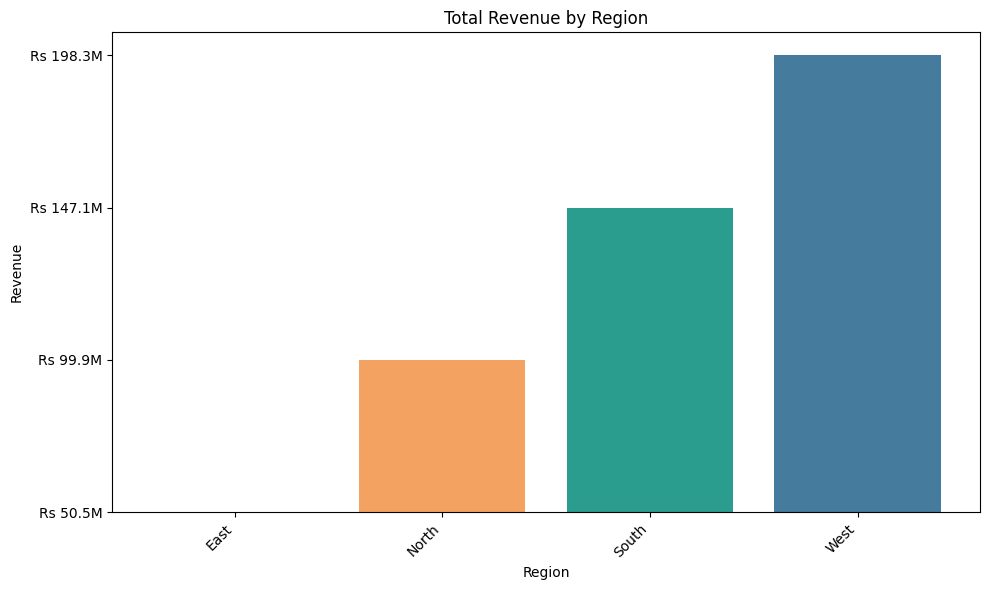

In [19]:
import matplotlib.pyplot as plt

top_products_pd = top_products.toPandas()

# Create the bar plot
plt.figure(figsize=(10, 6))

colors = ['#E63946', '#F4A261', '#2A9D8F', '#457B9D']

plt.bar(
    top_products_pd['region'],
    top_products_pd['total_revenue'],
    color=colors
)

plt.xlabel('Region')
plt.ylabel('Revenue')
plt.title('Total Revenue by Region')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

plt.show()